In [1]:
print("="*40)
print("Importing necessary libraries")
print("="*40)
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.sparse.linalg import eigsh
import pandas as pd
import multiprocessing as mp
import os
import time

Importing necessary libraries


In [2]:
print("="*40)
print("Defining functions for SIS model simulation")
print("="*40)

def get_leading_eigenvalue(G):
    """Calculates lambda_1 to determine the epidemic threshold 1/lambda_1."""
    adj_matrix = nx.adjacency_matrix(G).astype(float)
    eigenvalues = eigsh(adj_matrix, k=1, which='LA', return_eigenvectors=False)
    return eigenvalues[0]

def sis_parallel_step(G, current_status, beta, gamma, nodes_list, node_index):
    """Updates node statuses for time t based strictly on statuses at t-1."""
    new_status = current_status.copy()
    for i, u in enumerate(nodes_list):
        if current_status[i] == 1:
            # Recovery probability y
            if np.random.random() < gamma:
                new_status[i] = 0
        else:
            # Infection attempt for each neighbor with probability beta
            inf_neighbors = 0
            for v in G.neighbors(u):
                if current_status[node_index[v]] == 1:
                    inf_neighbors += 1
            if inf_neighbors > 0:
                # Probability of being infected by at least one neighbor: 1 - (1 - beta)^k
                p_infection = 1 - (1 - beta)**inf_neighbors
                if np.random.random() < p_infection:
                    new_status[i] = 1
    return new_status

def single_monte_carlo_run(args):
    """Execution of a single SIS simulation run."""
    G, beta, gamma, p0, steps = args
    nodes_list = list(G.nodes())
    node_index = {u: i for i, u in enumerate(nodes_list)}
    n = len(nodes_list)
    
    # Initially, random fraction p0 nodes are infected
    status = np.random.choice([0, 1], size=n, p=[1-p0, p0])
    history = [np.mean(status)]
    for _ in range(steps):
        status = sis_parallel_step(G, status, beta, gamma, nodes_list, node_index)
        history.append(np.mean(status))
    return history

def run_monte_carlo(G, beta, gamma, p0, steps, iterations, parallel=True):
    """Runs multiple simulations either sequentially or in parallel."""
    args = (G, beta, gamma, p0, steps)
    start_time = time.time()
    
    if parallel and iterations > 1:
        num_cores = max(1, os.cpu_count() - 1)
        print(f"   -> Running {iterations} iterations in PARALLEL ({num_cores} cores)", end=" ", flush=True)
        args_list = [args for _ in range(iterations)]
        with mp.Pool(processes=num_cores) as pool:
            all_runs = pool.map(single_monte_carlo_run, args_list)
    else:
        print(f"   -> Running {iterations} iteration(s) SEQUENTIALLY", end=" ", flush=True)
        all_runs = [single_monte_carlo_run(args) for _ in range(iterations)]
    
    end_time = time.time()
    print(f"Done! ({end_time - start_time:.2f}s)")
    
    all_runs = np.array(all_runs)
    return np.mean(all_runs, axis=0), np.std(all_runs, axis=0)

Defining functions for SIS model simulation


In [ ]:
print("="*40)
print("Setting simulation parameters and initializing networks")
print("="*40)

N = 1000              # Size
ITERATIONS = 100      # Number of Monte Carlo iterations
STEPS = 50            # Time steps
P0 = 0.1              # Initial infected fraction
PARALLEL_MODE = True  # True = Parallel, False = Sequential

# Initialize Networks
print(f"Generating {N}-node networks")
networks = {
    "Erdös-Rényi": nx.erdos_renyi_graph(N, 0.01),
    "Barábasi-Albert": nx.barabasi_albert_graph(N, 5),
    "Watts-Strogatz": nx.watts_strogatz_graph(N, 6, 0.1),
    "Complete": nx.complete_graph(N),
    "Star": nx.star_graph(N-1)
}

Setting simulation parameters and initializing networks
Generating 1000-node networks


Task 1: SIS Spread with Fixed Parameters
Processing Erdös-Rényi:
   -> Running 20 iteration(s) SEQUENTIALLY Done! (1.75s)
Processing Barábasi-Albert:
   -> Running 20 iteration(s) SEQUENTIALLY Done! (1.68s)
Processing Watts-Strogatz:
   -> Running 20 iteration(s) SEQUENTIALLY Done! (1.58s)
Processing Complete:
   -> Running 20 iteration(s) SEQUENTIALLY Done! (61.85s)
Processing Star:
   -> Running 20 iteration(s) SEQUENTIALLY Done! (1.00s)


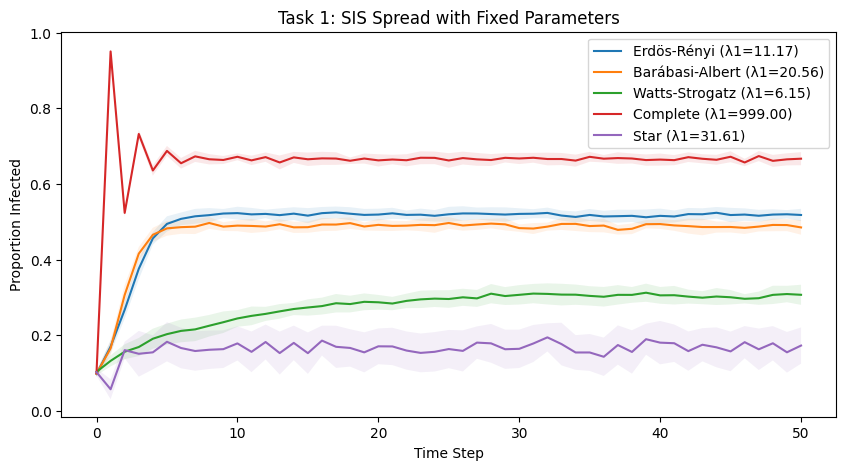

           Network      λ1 Inf% (Mean) Inf% (STD)
0      Erdös-Rényi   11.17      51.81%      1.62%
1  Barábasi-Albert   20.56      48.52%      1.92%
2   Watts-Strogatz    6.15      30.72%      2.65%
3         Complete  999.00      66.69%      1.73%
4             Star   31.61      17.30%      4.78%


In [4]:
print("="*40)
print("Task 1: SIS Spread with Fixed Parameters")
print("="*40)

B_FIXED, G_FIXED = 0.15, 0.5
plt.figure(figsize=(10, 5))
task1_res = []

# Updated loop for Task 1
for name, G in networks.items():
    print(f"Processing {name}:")
    l1 = get_leading_eigenvalue(G)
    avg, std = run_monte_carlo(G, B_FIXED, G_FIXED, P0, STEPS, ITERATIONS, parallel=PARALLEL_MODE)
    
    plt.plot(avg, label=f"{name} (λ1={l1:.2f})")
    if ITERATIONS > 1:
        plt.fill_between(range(len(avg)), avg-std, avg+std, alpha=0.1)
    
    task1_res.append({
        "Network": name, 
        "λ1": round(l1, 2), 
        "Inf% (Mean)": f"{avg[-1]*100:.2f}%",
        "Inf% (STD)": f"{std[-1]*100:.2f}%"
    })

plt.title("Task 1: SIS Spread with Fixed Parameters")
plt.xlabel("Time Step"); plt.ylabel("Proportion Infected")
plt.legend(); plt.show()
print(pd.DataFrame(task1_res))

Task 2: SIS Spread Around Threshold
Processing Erdös-Rényi:
   -> Running 20 iteration(s) SEQUENTIALLY Done! (2.68s)
   -> Running 20 iteration(s) SEQUENTIALLY Done! (2.00s)
Processing Barábasi-Albert:
   -> Running 20 iteration(s) SEQUENTIALLY Done! (2.13s)
   -> Running 20 iteration(s) SEQUENTIALLY Done! (1.67s)
Processing Watts-Strogatz:
   -> Running 20 iteration(s) SEQUENTIALLY Done! (1.66s)
   -> Running 20 iteration(s) SEQUENTIALLY Done! (1.32s)
Processing Complete:
   -> Running 20 iteration(s) SEQUENTIALLY Done! (135.66s)
   -> Running 20 iteration(s) SEQUENTIALLY Done! (117.59s)
Processing Star:
   -> Running 20 iteration(s) SEQUENTIALLY Done! (0.72s)
   -> Running 20 iteration(s) SEQUENTIALLY Done! (0.67s)


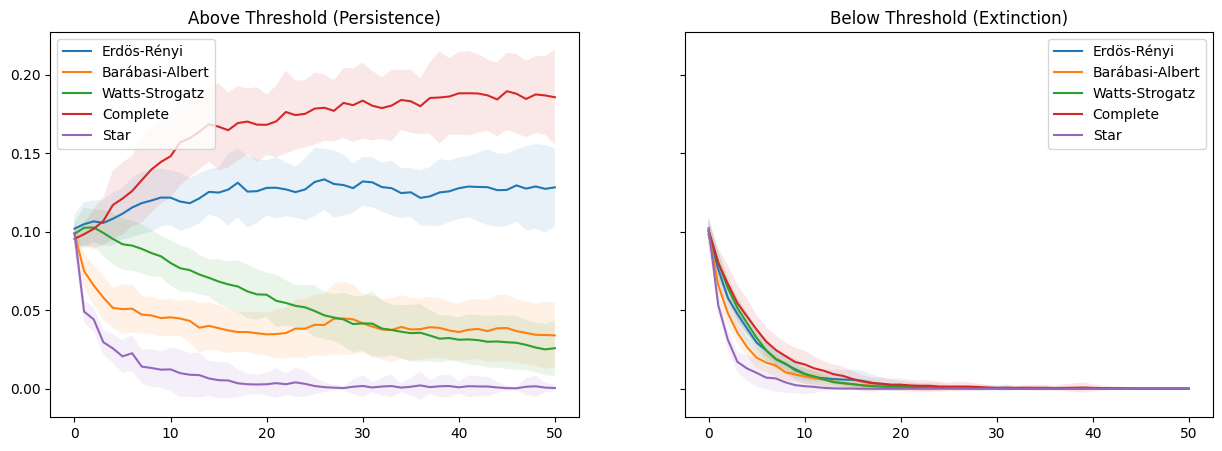

           Network  Threshold  Consistent
0      Erdös-Rényi     0.0896        True
1  Barábasi-Albert     0.0486        True
2   Watts-Strogatz     0.1625        True
3         Complete     0.0010        True
4             Star     0.0316        True


In [5]:
print("="*40)
print("Task 2: SIS Spread Around Threshold")
print("="*40)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
task2_res = []
GAMMA = 0.5

for name, G in networks.items():
    print(f"Processing {name}:")
    l1 = get_leading_eigenvalue(G)
    tau = 1/l1 # Threshold 
    
    # Values slightly above and below threshold 
    b_high, b_low = 1.3*(tau*GAMMA), 0.7*(tau*GAMMA)
    
    # Above Threshold
    avg_h, std_h = run_monte_carlo(G, b_high, GAMMA, P0, STEPS, ITERATIONS, parallel=PARALLEL_MODE)
    ax1.plot(avg_h, label=name)
    if ITERATIONS > 1: ax1.fill_between(range(len(avg_h)), avg_h-std_h, avg_h+std_h, alpha=0.1)
    
    # Below Threshold
    avg_l, std_l = run_monte_carlo(G, b_low, GAMMA, P0, STEPS, ITERATIONS, parallel=PARALLEL_MODE)
    ax2.plot(avg_l, label=name)
    if ITERATIONS > 1: ax2.fill_between(range(len(avg_l)), avg_l-std_l, avg_l+std_l, alpha=0.1)
    
    task2_res.append({"Network": name, "Threshold": round(tau, 4), "Consistent": avg_h[-1] > avg_l[-1]})

ax1.set_title("Above Threshold (Persistence)"); ax2.set_title("Below Threshold (Extinction)")
ax1.legend(); ax2.legend(); plt.show()
print(pd.DataFrame(task2_res))